In [2]:
import sys
from pathlib import Path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent

sys.path.append(str(ROOT))
import networkx as nx 
import torch
from node2vec import Node2Vec
from torch_geometric.datasets import Planetoid
from src.methods.posEnc import LaplacianPosEnc
from src.models.mlp import MLP
from src.plotting import visualize_embeddings_grid
from src.models.svm import evaluate_with_svm

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
dataset = Planetoid(root='~/datasets/Cora', name='Cora')
data = dataset[0]
data = data.to(device)
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [17]:
# node2vec

G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
G.add_edges_from(data.edge_index.t().tolist())

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=30, 
    num_walks=20, 
    p=1.0,
    q=0.5, 
    workers=4
)

model = node2vec.fit(window = 10, min_count=1, batch_words=5)
emb_node2vec = torch.tensor([model.wv[str(n)] for n in range(data.num_nodes)])

print(emb_node2vec.shape) 

Computing transition probabilities:   0%|          | 0/2708 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 5/5 [00:00<00:00,  6.60it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


torch.Size([2708, 64])


In [3]:
# posEnc

pos_enc = LaplacianPosEnc(k=32)
data_posEnc = pos_enc(data)
emb_posEnc = data_posEnc.x

print(emb_posEnc.shape)

torch.Size([2708, 1465])


In [ ]:
# original features
emb_original = data.x.clone().to(device)
print(emb_original)


tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.0174e-02,
          5.3217e-04,  9.4119e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.0382e-02,
          3.9414e-03,  6.5834e-04],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -5.6582e-03,
          4.8673e-03, -9.5313e-04],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  9.9081e-09,
         -7.3880e-10,  1.6672e-08],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.9319e-02,
         -9.3630e-03,  2.8281e-02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -1.7488e-02,
         -1.0963e-02,  2.7642e-02]], device='mps:0')


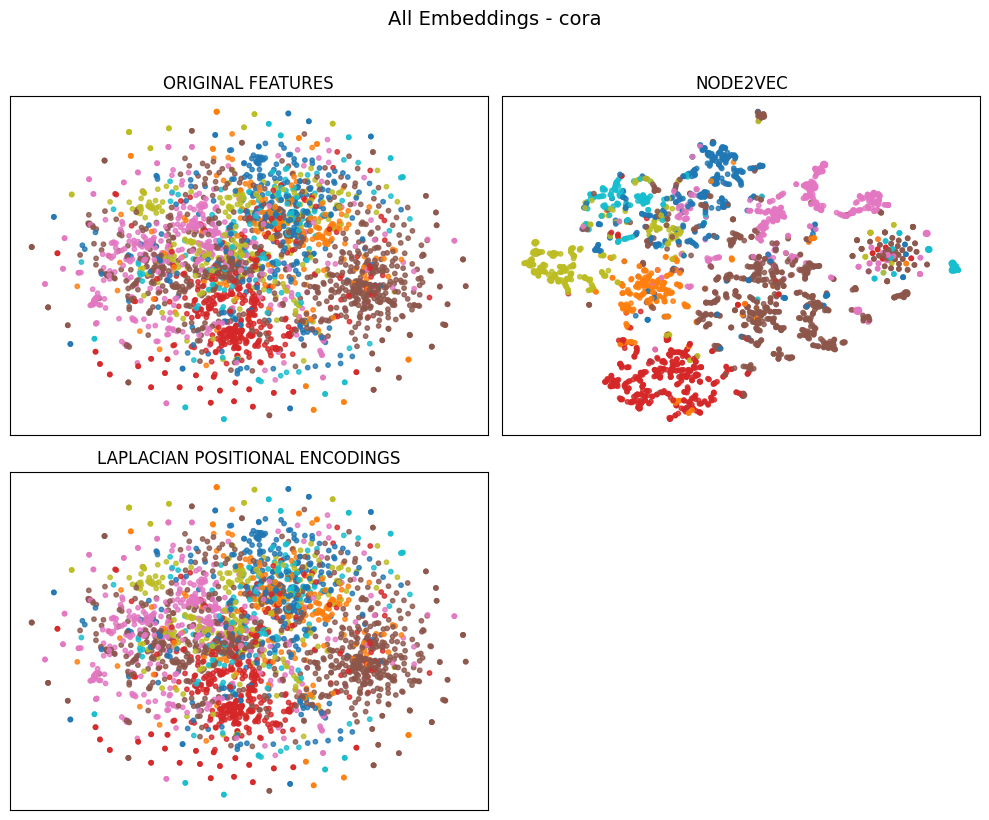

In [ ]:
labels = data.y
all_embeddings = {
    "Original Features": emb_original.cpu(),
    "Node2Vec": emb_node2vec.cpu(),
    "Laplacian Positional Encodings": emb_posEnc.cpu()
}
visualize_embeddings_grid(all_embeddings, labels, title= "All Embeddings - cora")



MLP on LAPLACIANPOSENC embeddings
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=1e-05 | Val 0.4920
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0001 | Val 0.5260
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.0005, wd=0.0005 | Val 0.5320
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=1e-05 | Val 0.5600
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0001 | Val 0.4820
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.001, wd=0.0005 | Val 0.5400
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=1e-05 | Val 0.5540
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0001 | Val 0.5440
[LAPLACIANPOSENC] h1=128, h2=128, d=0.0, lr=0.002, wd=0.0005 | Val 0.5140
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=1e-05 | Val 0.4940
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0001 | Val 0.5000
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.0005, wd=0.0005 | Val 0.4980
[LAPLACIANPOSENC] h1=128, h2=128, d=0.1, lr=0.001, wd=1e-05 | Val 0.5280
[L

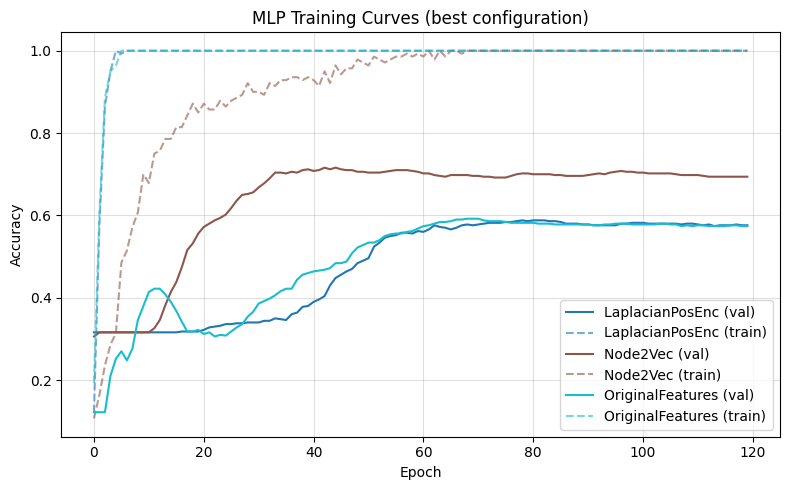

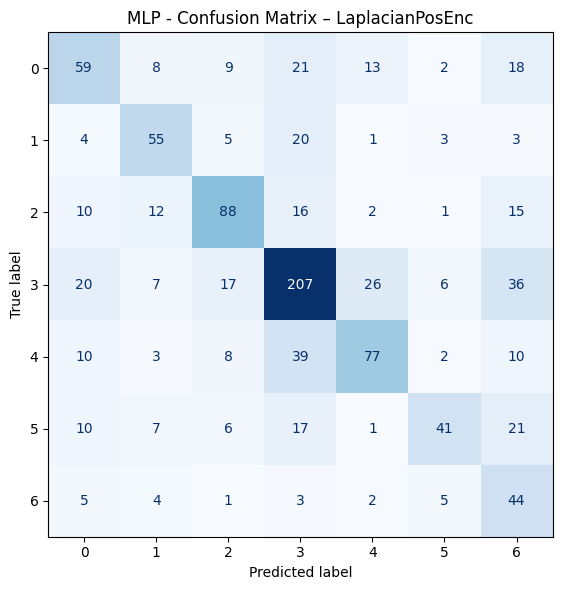

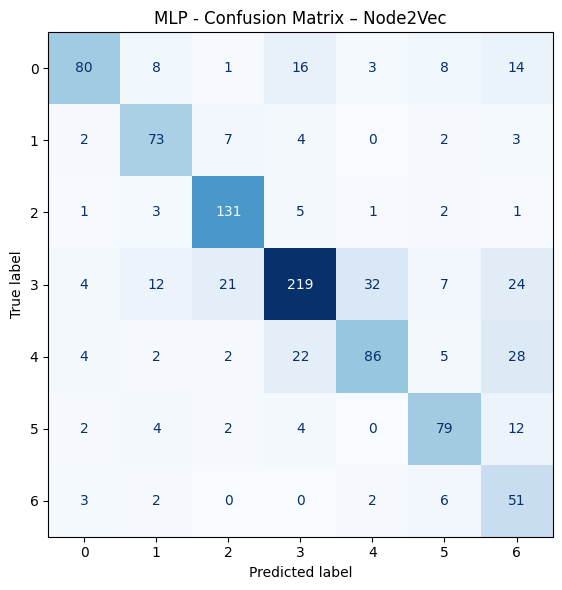

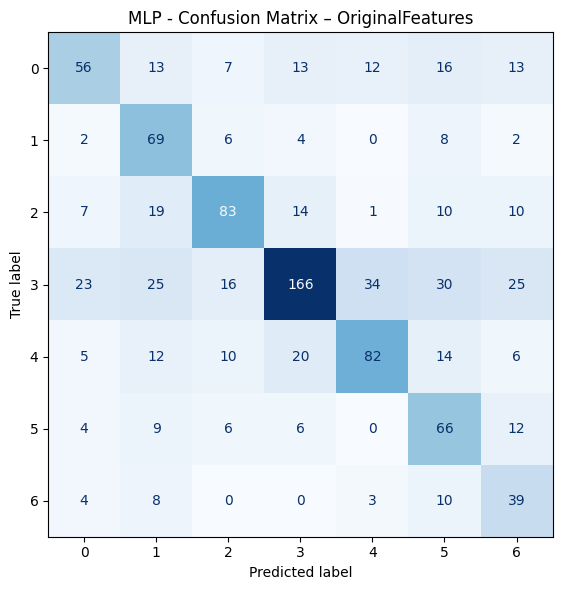

In [ ]:
# evaluate with MLP

results_dir = Path("/Users/emely/Uni/Thesis/Thesis/cora/results")
results_dir.mkdir(parents=True, exist_ok=True)

embeddings = {"LaplacianPosEnc": emb_posEnc, "Node2Vec": emb_node2vec, "OriginalFeatures": emb_original}

best_results, best_acc = MLP.evaluate_with_mlp(
    embeddings=embeddings,
    data=data,
    device=device,
    mlp_epochs=120
)

torch.save(best_acc, results_dir / "best_acc_node_pos.pt")
emb_file = Path("/Users/emely/Uni/Thesis/Thesis/cora/results/embeddings.pt")

if emb_file.exists():
    all_embeddings = torch.load(emb_file)
else:
    all_embeddings = {}

for name, emb_tensor in embeddings.items():
    all_embeddings[name] = {name: emb_tensor.detach().cpu()}

torch.save(all_embeddings, emb_file)

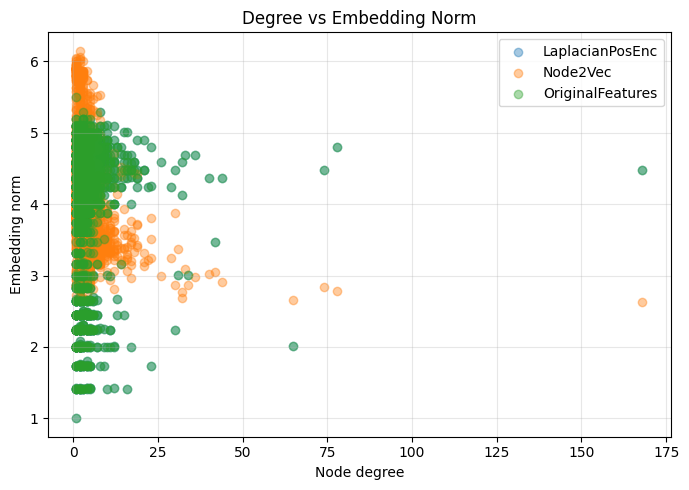

In [22]:
import matplotlib.pyplot as plt

degrees = torch.tensor([G.degree(n) for n in range(data.num_nodes)])

plt.figure(figsize=(7, 5))

for name, emb in embeddings.items():
    norms = emb.norm(dim=1).cpu() 
    plt.scatter(degrees, norms, alpha=0.4, label=name)

plt.xlabel("Node degree")
plt.ylabel("Embedding norm")
plt.title("Degree vs Embedding Norm")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



SVM on LAPLACIANPOSENC embeddings
C=0.01 | Val Acc=0.5440
C=0.1 | Val Acc=0.5600
C=1 | Val Acc=0.5800
C=10 | Val Acc=0.5780
Best C=1 | Test Acc=0.6000


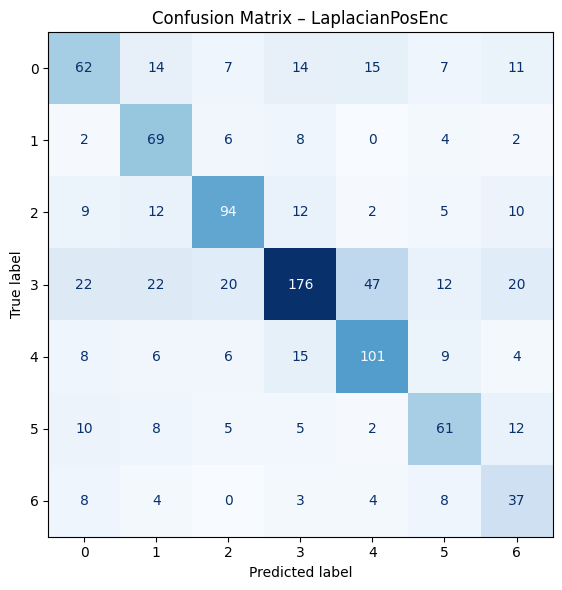


SVM on NODE2VEC embeddings
C=0.01 | Val Acc=0.6580
C=0.1 | Val Acc=0.6700
C=1 | Val Acc=0.6720
C=10 | Val Acc=0.6380
Best C=1 | Test Acc=0.6990


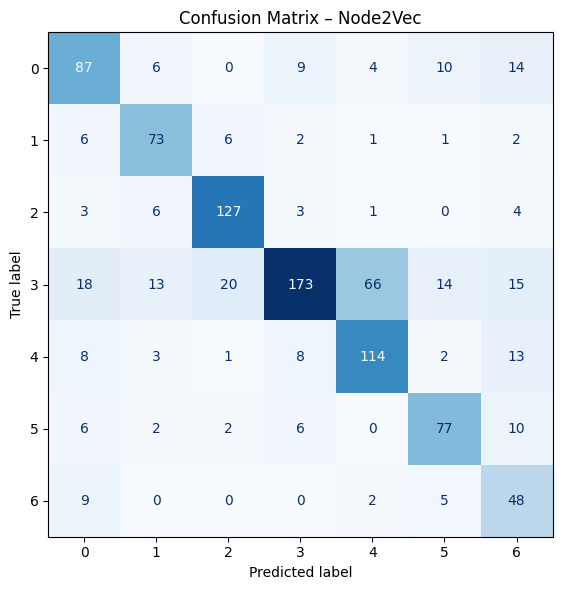


SVM on ORIGINALFEATURES embeddings
C=0.01 | Val Acc=0.5440
C=0.1 | Val Acc=0.5600
C=1 | Val Acc=0.5800
C=10 | Val Acc=0.5780
Best C=1 | Test Acc=0.6000


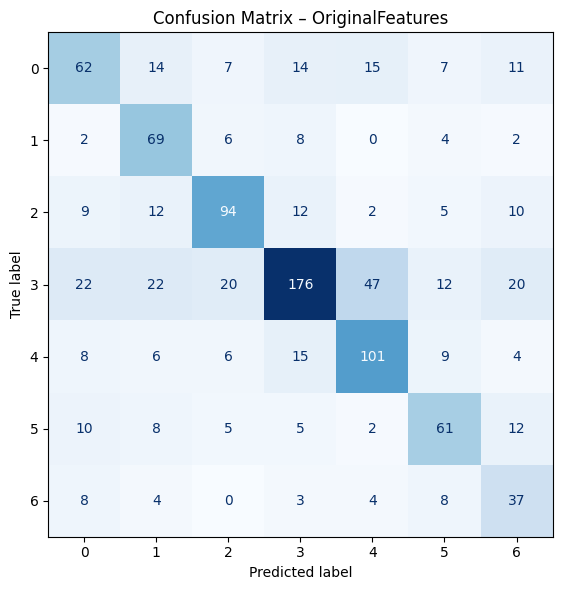

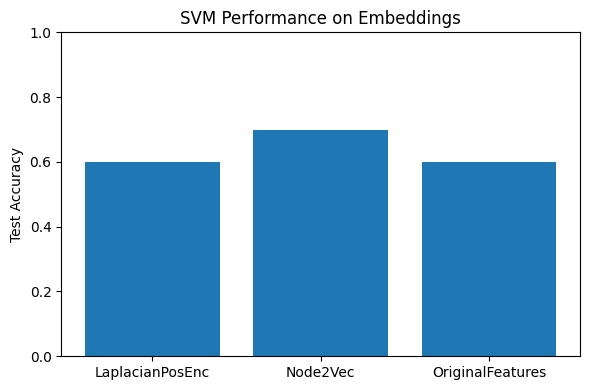

In [ ]:
# evaluate with SVM

svm_results = evaluate_with_svm(
    embeddings=embeddings,
    data=data,
    device=device
)
torch.save(svm_results,"/Users/emely/Uni/Thesis/Thesis/cora/results/svm_results_node_pos.pt")